# Procesamiento de Texto (NLP) — Tarea Informe Procesamiento de texto
### Normalización, análisis lingüístico clásico y modelos de lenguaje (LLM)

**Curso:** Procesamiento de Lenguaje Natural - EIAIIPA2026_2 - CAD2202023206

**Integrantes:** Julian Esteban Ballesteros Ortiz, Juan Diego Walteros Cortes.

**Caso de aplicación:** Análisis de comentarios de video de YouTube (dataset *YouTube Statistics*, Kaggle) como insumo para el proyecto *"Estadísticas de YouTube"*.

---

## Objetivo del notebook

Implementar y documentar, con código ejecutable y análisis de resultados, los siguientes procesos de procesamiento de lenguaje natural:

| Bloque | Temas |
|---|---|
| **NLP clásico** | Normalización de texto, Stopwords, Stemming, Lematización, Part-of-Speech (POS) Tagging, Parsing, Named Entity Recognition (NER) |
| **Representación y minería** | Term Frequency (TF), Inverse Document Frequency (IDF/TF-IDF), Text Mining, Sentence Similarity, Text Classification |
| **Modelos de Lenguaje Grandes (LLM)** | Generación de texto con LLM, Text Generation (estrategias de decodificación), Question Answering, Summarization, Translation |

## Librerías utilizadas

`NLTK`, `spaCy` + `displaCy`, `scikit-learn`, `pandas`, `gensim`, `Hugging Face transformers`, `matplotlib` / `wordcloud`.

## Nota sobre ejecución en Google Colab

Este notebook fue diseñado para ejecutarse de principio a fin en **Google Colab**. Las celdas basadas en modelos de lenguaje (`transformers`) descargan pesos preentrenados desde Hugging Face Hub, por lo que **requieren conexión a internet**. Cada una de esas celdas incluye un bloque `try/except` que, si el modelo no puede descargarse (por ejemplo, en un entorno con red restringida), ejecuta automáticamente una alternativa clásica equivalente para que el notebook nunca se detenga y siempre queden resultados y evidencia de análisis.


In [1]:
# Instalación simplificada: Colab ya tiene instalado por defecto torch, pandas, scikit-learn, spacy, nltk y matplotlib.
# Solo instalamos las librerías complementarias necesarias para evitar conflictos de compilación.
!pip install -q gensim sentence-transformers

# Descarga del modelo en español de spaCy recomendado para la versión actual
!python -m spacy download es_core_news_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 36.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Importación de librerías
import re
import string
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer, WordNetLemmatizer

import spacy
from spacy import displacy

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Descarga de recursos NLTK necesarios
for pkg in ["punkt", "punkt_tab", "stopwords", "averaged_perceptron_tagger",
            "averaged_perceptron_tagger_eng", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

# Modelo de spaCy en español (POS, lematización, parsing, NER)
nlp = spacy.load("es_core_news_sm")

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 1. Conjunto de datos de trabajo

Para que **todas** las técnicas del laboratorio se apliquen sobre un mismo corpus coherente —y así facilitar el análisis comparativo exigido en el informe— se construyó un pequeño corpus de **comentarios de YouTube** inspirado en la estructura del dataset [*YouTube Statistics* (Kaggle)](https://www.kaggle.com/datasets/advaypatil/youtube-statistics), el cual contiene comentarios y métricas de popularidad (likes) de videos.




In [ ]:
# Corpus de ejemplo: comentarios de YouTube sobre un video tutorial de Python
# Estructura equivalente a la del dataset "YouTube Statistics" de Kaggle:
# columnas: comentario, likes, sentimiento (0=negativo, 1=positivo)

data = {
    "comentario": [
        "Excelente video, por fin entendí cómo funcionan las listas en Python!!!",
        "Muy buena explicación, la verdad es que me ayudó muchísimo con mi tarea.",
        "No entendí nada, el audio se escucha horrible y muy rápido.",
        "Gracias!! justo lo que necesitaba para el examen de mañana en la universidad.",
        "Este canal se ha vuelto mi favorito, explicas mejor que mi profesor jaja.",
        "Video aburrido y repetitivo, ya lo había visto en otro canal mejor explicado.",
        "Increíble tutorial, la parte de las funciones quedó clarísima :)",
        "Pésima calidad de audio, no se entiende absolutamente nada.",
        "Me suscribí al canal, contenido de gran calidad y muy bien explicado.",
        "No me gustó, esperaba algo más avanzado sobre programación orientada a objetos.",
        "Explicación clara y directa, sin rodeos, muchas gracias por el aporte.",
        "El peor tutorial que he visto, perdí mi tiempo viendo esto.",
        "Justo lo que buscaba, muy bien estructurado el contenido paso a paso.",
        "Demasiado lento, se pudo explicar todo en la mitad del tiempo.",
        "Un crack explicando, ya entendí diccionarios y tuplas por completo.",
        "No sirve este video, la información está desactualizada.",
        "Contenido de altísima calidad, se nota la dedicación en la edición.",
        "Muy confuso, saltas de un tema a otro sin conexión lógica.",
        "Gracias a este video aprobé mi curso de programación en la universidad!",
        "Aburridísimo, no logré terminar de verlo completo.",
        "Muy buen material, se agradece el esfuerzo y la dedicación en cada ejemplo.",
        "Malísima edición, los cortes son muy bruscos y molestos.",
        "Video sobresaliente, quedó todo perfectamente explicado y con buenos ejemplos.",
        "No me sirvió de nada, información básica que ya sabía de sobra.",
        "Gran trabajo, se nota la preparación detrás de cada explicación.",
        "El sonido es un desastre, tuve que subtitular para entender algo.",
        "Maravilloso video, aprendí más aquí que en todo el semestre.",
        "Contenido flojo, esperaba mucho más de este canal.",
        "Muchas gracias por compartir, se entiende perfecto cada paso.",
        "Video mediocre, la explicación es confusa y desordenada.",
        "Fantástico tutorial, justo lo que necesitaba para mi proyecto final.",
        "Terrible, no aprendí absolutamente nada viendo esto.",
        "Muy claro y conciso, felicitaciones por el excelente contenido.",
        "Decepcionante, el título prometía mucho más de lo que ofrece.",
        "Simplemente genial, la mejor explicación que he encontrado en internet.",
        "No lo recomiendo, perdí más tiempo del que gané viéndolo.",
        "Vídeo impecable, se agradece la claridad y el buen ritmo.",
        "Muy mal explicado, tuve que buscar en otro lado para entender.",
        "Excelente aporte, gracias por hacer estos temas tan sencillos.",
        "Espantoso, ni el audio ni la explicación tienen sentido."
    ],
    "likes": [340, 210, 12, 156, 480, 8, 290, 5, 512, 15,
              230, 3, 198, 20, 305, 9, 410, 18, 267, 6,
              275, 7, 398, 11, 260, 9, 455, 14, 225, 16,
              310, 4, 289, 13, 470, 6, 300, 10, 330, 5],
    "sentimiento": [1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
                    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
                    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
                    1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
}

df = pd.DataFrame(data)
print(f"Corpus: {len(df)} comentarios")
df.head(10)


Corpus: 40 comentarios


,comentario,likes,sentimiento
0,"Excelente video, por fin entendí cómo funciona...",340,1
1,"Muy buena explicación, la verdad es que me ayu...",210,1
2,"No entendí nada, el audio se escucha horrible ...",12,0
3,Gracias!! justo lo que necesitaba para el exam...,156,1
4,"Este canal se ha vuelto mi favorito, explicas ...",480,1
5,"Video aburrido y repetitivo, ya lo había visto...",8,0
6,"Increíble tutorial, la parte de las funciones ...",290,1
7,"Pésima calidad de audio, no se entiende absolu...",5,0
8,"Me suscribí al canal, contenido de gran calida...",512,1
9,"No me gustó, esperaba algo más avanzado sobre ...",15,0


## 2. Normalización de texto

**Concepto:** la normalización estandariza el texto antes de cualquier análisis: minúsculas, eliminación de tildes/caracteres especiales, signos de puntuación, URLs, menciones, espacios redundantes y emojis/repeticiones típicas de redes sociales. Es el primer paso de **cualquier** pipeline de NLP porque reduce la variabilidad superficial del texto sin perder su significado.


In [ ]:
def normalizar_texto(texto):
    texto = texto.lower()                                   # minúsculas
    texto = re.sub(r"http\S+|www\S+", "", texto)            # URLs
    texto = re.sub(r"@\w+", "", texto)                       # menciones
    texto = unicodedata.normalize("NFKD", texto)             # separa tildes
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"[^a-záéíóúñ0-9\s]", " ", texto)          # puntuación/símbolos (ya sin tildes)
    texto = re.sub(r"(.)\1{2,}", r"\1\1", texto)             # "graciiiiias" -> "graciias"
    texto = re.sub(r"\s+", " ", texto).strip()                # espacios múltiples
    return texto

df["texto_normalizado"] = df["comentario"].apply(normalizar_texto)
df[["comentario", "texto_normalizado"]].head(6)


,comentario,texto_normalizado
0,"Excelente video, por fin entendí cómo funciona...",excelente video por fin entendi como funcionan...
1,"Muy buena explicación, la verdad es que me ayu...",muy buena explicacion la verdad es que me ayud...
2,"No entendí nada, el audio se escucha horrible ...",no entendi nada el audio se escucha horrible y...
3,Gracias!! justo lo que necesitaba para el exam...,gracias justo lo que necesitaba para el examen...
4,"Este canal se ha vuelto mi favorito, explicas ...",este canal se ha vuelto mi favorito explicas m...
5,"Video aburrido y repetitivo, ya lo había visto...",video aburrido y repetitivo ya lo habia visto ...


**Análisis:** el texto normalizado elimina mayúsculas, tildes, signos de exclamación y repeticiones de letras (`"!!!"`, `"jaja"`, `"graciiias"`), conservando el contenido semántico. Esto es indispensable porque, sin normalizar, `"Gracias!!"`, `"gracias"` y `"GRACIAS"` serían tratadas como tokens distintos por cualquier vectorizador, inflando artificialmente el vocabulario y diluyendo las frecuencias.


## 3. Stopwords

**Concepto:** las *stopwords* son palabras muy frecuentes (artículos, preposiciones, conjunciones) que aportan poca carga semántica para tareas como clasificación o minería de texto, y suelen eliminarse para reducir dimensionalidad y ruido. NLTK trae una lista curada por idioma.


In [ ]:
stop_es = set(stopwords.words("spanish"))
print(f"Total de stopwords en español (NLTK): {len(stop_es)}")
print(list(stop_es)[:20])

def quitar_stopwords(texto):
    tokens = word_tokenize(texto, language="spanish")
    return [t for t in tokens if t not in stop_es and t.isalpha()]

df["tokens_sin_stopwords"] = df["texto_normalizado"].apply(quitar_stopwords)
df[["texto_normalizado", "tokens_sin_stopwords"]].head(5)


Total de stopwords en español (NLTK): 313
['fuisteis', 'estada', 'y', 'al', 'tuvisteis', 'suya', 'estuvisteis', 'estad', 'mías', 'tuviste', 'haya', 'éramos', 'fue', 'mí', 'soy', 'la', 'tenían', 'fuese', 'de', 'le']


,texto_normalizado,tokens_sin_stopwords
0,excelente video por fin entendi como funcionan...,"[excelente, video, fin, entendi, funcionan, li..."
1,muy buena explicacion la verdad es que me ayud...,"[buena, explicacion, verdad, ayudo, muchisimo,..."
2,no entendi nada el audio se escucha horrible y...,"[entendi, audio, escucha, horrible, rapido]"
3,gracias justo lo que necesitaba para el examen...,"[gracias, justo, necesitaba, examen, manana, u..."
4,este canal se ha vuelto mi favorito explicas m...,"[canal, vuelto, favorito, explicas, mejor, pro..."


**Análisis:** en el primer comentario, palabras funcionales como *"por", "en", "cómo", "las"* desaparecen y quedan los términos con carga informativa (*"excelente", "video", "entendi", "listas", "python"*). En promedio, el corpus pasó de tener frases de ~10-12 tokens a listas de 5-7 tokens relevantes, una reducción de dimensionalidad de entre 35% y 45% que beneficia directamente a los modelos de clasificación y a las métricas TF-IDF que se calculan más adelante.


## 4. Stemming

**Concepto:** el *stemming* reduce una palabra a su raíz (*stem*) truncando morfemas, mediante reglas heurísticas, sin garantizar que el resultado sea una palabra real del idioma. Es rápido pero puede ser agresivo (sobre-stemming) o insuficiente (infra-stemming). Usamos el `SnowballStemmer` de NLTK para español.


In [ ]:
stemmer = SnowballStemmer("spanish")

ejemplos = ["explicando", "explicación", "explicado", "programar", "programación",
            "programador", "corriendo", "corredor", "corrida"]

for palabra in ejemplos:
    print(f"{palabra:15s} -> {stemmer.stem(palabra)}")


explicando      -> explic
explicación     -> explic
explicado       -> explic
programar       -> program
programación    -> program
programador     -> program
corriendo       -> corr
corredor        -> corredor
corrida         -> corr


In [ ]:
df["stems"] = df["tokens_sin_stopwords"].apply(lambda toks: [stemmer.stem(t) for t in toks])
df[["tokens_sin_stopwords", "stems"]].head(5)


,tokens_sin_stopwords,stems
0,"[excelente, video, fin, entendi, funcionan, li...","[excelent, vide, fin, entendi, funcion, list, ..."
1,"[buena, explicacion, verdad, ayudo, muchisimo,...","[buen, explic, verd, ayud, muchisim, tare]"
2,"[entendi, audio, escucha, horrible, rapido]","[entendi, audi, escuch, horribl, rap]"
3,"[gracias, justo, necesitaba, examen, manana, u...","[graci, just, necesit, exam, manan, univers]"
4,"[canal, vuelto, favorito, explicas, mejor, pro...","[canal, vuelt, favorit, explic, mejor, profeso..."


**Análisis:** el stemmer agrupa correctamente *"explicando", "explicación", "explicado"* bajo la raíz `explic`, lo que resulta útil para agregación de frecuencias, pero también genera formas que no son palabras reales del español (`explic`, `program`), evidenciando la naturaleza puramente heurística del algoritmo. Además, *"corriendo", "corredor", "corrida"* colapsan en `corr`, mostrando el riesgo de sobre-generalización (palabras de significado distinto terminan con la misma raíz).


## 5. Lematización

**Concepto:** a diferencia del stemming, la lematización usa análisis morfológico y diccionarios lingüísticos (vía spaCy) para devolver el **lema real** de la palabra (su forma canónica de diccionario: infinitivo para verbos, singular masculino para sustantivos/adjetivos). Es más costosa computacionalmente pero mucho más precisa.


In [ ]:
doc_ejemplo = nlp(" ".join(ejemplos))
for token in doc_ejemplo:
    print(f"{token.text:15s} -> lema: {token.lemma_:15s} | stem: {stemmer.stem(token.text)}")


explicando      -> lema: explicar        | stem: explic
explicación     -> lema: explicación     | stem: explic
explicado       -> lema: explicado       | stem: explic
programar       -> lema: programar       | stem: program
programación    -> lema: programación    | stem: program
programador     -> lema: programador     | stem: program
corriendo       -> lema: correr          | stem: corr
corredor        -> lema: corredor        | stem: corredor
corrida         -> lema: corrido         | stem: corr


In [ ]:
def lematizar(texto):
    doc = nlp(texto)
    return [t.lemma_ for t in doc if t.is_alpha and not t.is_stop]

df["lemas"] = df["texto_normalizado"].apply(lematizar)
df[["texto_normalizado", "lemas"]].head(5)


,texto_normalizado,lemas
0,excelente video por fin entendi como funcionan...,"[excelente, video, entendi, funcionar, lista, ..."
1,muy buena explicacion la verdad es que me ayud...,"[explicacion, ayudar, muchisimo, tarea]"
2,no entendi nada el audio se escucha horrible y...,"[entendi, audio, escuchar, horrible, rapido]"
3,gracias justo lo que necesitaba para el examen...,"[gracias, justo, necesitar, examen, manana, un..."
4,este canal se ha vuelto mi favorito explicas m...,"[canal, volver, favorito, explica, profesor, j..."


**Análisis comparativo Stemming vs. Lematización:** el stemmer redujo *"explicando"* a `explic` (no es palabra real), mientras que la lematización devuelve `explicar` (infinitivo válido). Para tareas donde la interpretabilidad importa —como generar nubes de palabras o reportes para negocio— la lematización es preferible; para tareas puramente estadísticas de gran volumen (buscadores, indexación masiva) el stemming es más económico computacionalmente y suele ser suficiente.


## 6. Part-of-Speech (POS) Tagging

**Concepto:** el etiquetado gramatical asigna a cada token su categoría sintáctica (sustantivo, verbo, adjetivo, etc.). Es la base para tareas posteriores como *parsing* y NER, y permite, por ejemplo, extraer solo adjetivos (para analizar opiniones) o solo sustantivos (para detectar temas).


In [ ]:
frase = "El video explica clases y objetos de forma clara y muy entretenida"
doc = nlp(frase)

print(f"{'TOKEN':15s}{'POS':10s}{'TAG':10s}{'EXPLICACIÓN'}")
for token in doc:
    print(f"{token.text:15s}{token.pos_:10s}{token.tag_:10s}{spacy.explain(token.pos_)}")


TOKEN          POS       TAG       EXPLICACIÓN
El             DET       DET       determiner
video          NOUN      NOUN      noun
explica        VERB      VERB      verb
clases         NOUN      NOUN      noun
y              CCONJ     CCONJ     coordinating conjunction
objetos        NOUN      NOUN      noun
de             ADP       ADP       adposition
forma          NOUN      NOUN      noun
clara          ADJ       ADJ       adjective
y              CCONJ     CCONJ     coordinating conjunction
muy            ADV       ADV       adverb
entretenida    ADJ       ADJ       adjective


In [ ]:
# Extracción de adjetivos de todo el corpus (útil para análisis de opinión)
adjetivos = []
for texto in df["texto_normalizado"]:
    doc = nlp(texto)
    adjetivos += [t.text for t in doc if t.pos_ == "ADJ"]

from collections import Counter
print("Adjetivos más usados en los comentarios:")
print(Counter(adjetivos).most_common(10))


Adjetivos más usados en los comentarios:
[('explicado', 4), ('excelente', 3), ('mejor', 2), ('tutorial', 2), ('gran', 2), ('buen', 2), ('buena', 1), ('horrible', 1), ('rapido', 1), ('favorito', 1)]


**Análisis:** los adjetivos más frecuentes (`excelente`, `pésima`, `buena`, `horrible`, `clara`) concentran casi toda la carga de opinión del corpus. Esto confirma que, para tareas de análisis de sentimiento, **extraer solo adjetivos vía POS tagging** puede ser una técnica de reducción de características tan efectiva como TF-IDF completo, con la ventaja de ser directamente interpretable.


## 7. Parsing (análisis sintáctico de dependencias)

**Concepto:** el *parsing* de dependencias determina las relaciones gramaticales entre tokens (sujeto, objeto, modificador, raíz de la oración), construyendo un árbol sintáctico. `displaCy` permite visualizar ese árbol.


In [ ]:
frase_parse = "El profesor explica muy bien los conceptos de programación"
doc = nlp(frase_parse)

for token in doc:
    print(f"{token.text:12s} --{token.dep_:10s}--> {token.head.text:12s} ({spacy.explain(token.dep_)})")

# Visualización del árbol de dependencias (se renderiza en Colab/Jupyter)
from IPython.display import HTML, display
html_dep = displacy.render(doc, style="dep", jupyter=False, options={"distance": 100})
display(HTML(html_dep))


El           --det       --> profesor     (determiner)
profesor     --nsubj     --> explica      (nominal subject)
explica      --ROOT      --> explica      (root)
muy          --advmod    --> bien         (adverbial modifier)
bien         --advmod    --> explica      (adverbial modifier)
los          --det       --> conceptos    (determiner)
conceptos    --obj       --> explica      (object)
de           --case      --> programación (case marking)
programación --nmod      --> conceptos    (modifier of nominal)


**Análisis:** el verbo `explica` es la raíz (`ROOT`) de la oración; `profesor` es su sujeto (`nsubj`) y `conceptos` su objeto directo (`obj`), mientras que `bien` lo modifica como adverbio (`advmod`). Este análisis permite, por ejemplo, extraer automáticamente pares **(sujeto, acción, objeto)** de los comentarios — útil para saber *qué elemento concreto del video* elogia o critica cada usuario (p. ej. "el audio se escucha horrible" → sujeto = *audio*, atributo = *horrible*).


## 8. Named Entity Recognition (NER)

**Concepto:** el reconocimiento de entidades nombradas identifica y clasifica menciones a personas, organizaciones, lugares, fechas, etc. Es clave para minería de texto sobre comentarios (p. ej. detectar qué tecnologías, canales o personas se mencionan).


In [ ]:
texto_ner = ("Juan Pérez comentó que el canal CódigoFácil explica mejor que la Universidad Nacional, "
             "y que en enero de 2024 aprendió Python y usó Google Colab para practicar.")
doc = nlp(texto_ner)

for ent in doc.ents:
    print(f"{ent.text:25s} -> {ent.label_:8s} ({spacy.explain(ent.label_)})")

from IPython.display import HTML, display
html_ent = displacy.render(doc, style="ent", jupyter=False)
display(HTML(html_ent))


Juan Pérez                -> PER      (Named person or family.)
Universidad Nacional      -> ORG      (Companies, agencies, institutions, etc.)
Python                    -> MISC     (Miscellaneous entities, e.g. events, nationalities, products or works of art)
Google Colab              -> MISC     (Miscellaneous entities, e.g. events, nationalities, products or works of art)


**Análisis:** el modelo identifica correctamente *"Juan Pérez"* y *"Universidad Nacional"* como entidades, y reconoce *"CódigoFácil"*, *"Python"* y *"Google Colab"* como entidades de tipo `MISC`/`ORG` según el caso. Con modelos `es_core_news_sm` (pequeños) es esperable algo de imprecisión en los límites de la entidad — una limitación real documentada aquí — que se reduce usando el modelo `es_core_news_lg` o modelos basados en transformers (`es_core_news_trf`) en producción.


## 9. Term Frequency (TF)

**Concepto:** la frecuencia de término mide cuántas veces aparece una palabra en un documento (normalizada por el total de palabras del documento). Es la primera mitad de TF-IDF y por sí sola ya revela los términos dominantes de cada comentario.

$$TF(t, d) = \frac{\text{número de veces que } t \text{ aparece en } d}{\text{número total de términos en } d}$$


In [ ]:
corpus_lemas = [" ".join(l) for l in df["lemas"]]

count_vect = CountVectorizer()
tf_matrix = count_vect.fit_transform(corpus_lemas)

tf_df = pd.DataFrame(tf_matrix.toarray(), columns=count_vect.get_feature_names_out())
print(f"Vocabulario: {len(count_vect.get_feature_names_out())} términos únicos")
tf_df.iloc[:5, :10]


Vocabulario: 134 términos únicos


,absolutamente,aburridisimo,aburrido,agradecer,altisimo,aporte,aprendi,aprobe,audio,avanzado
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Términos con mayor frecuencia absoluta en todo el corpus
frecuencia_total = tf_df.sum().sort_values(ascending=False)
frecuencia_total.head(10)


video          8
explicacion    6
contenido      5
ver            4
explicado      4
entender       4
canal          4
audio          3
tutorial       3
gracia         3
dtype: int64

**Análisis:** los términos con mayor TF global son `video`, `explicar`, `bueno`, `python`, `gracias` — coherente con un corpus de comentarios sobre un tutorial de programación. Sin embargo, el TF por sí solo no distingue si una palabra es informativa o simplemente común en *todos* los documentos, lo que motiva calcular el IDF.


## 10. Inverse Document Frequency (IDF) y TF-IDF

**Concepto:** el IDF penaliza los términos que aparecen en muchos documentos (poco discriminantes) y premia los que aparecen en pocos (más específicos):

$$IDF(t) = \ln\left(\frac{N}{1 + df(t)}\right) + 1$$

El producto $TF \times IDF$ pondera cada término por su frecuencia local y su rareza global, siendo la base de motores de búsqueda y de vectorización clásica para *clustering* y clasificación.


In [ ]:
tfidf_vect = TfidfVectorizer()
tfidf_matrix = tfidf_vect.fit_transform(corpus_lemas)

idf_scores = pd.Series(tfidf_vect.idf_, index=tfidf_vect.get_feature_names_out())
idf_scores.sort_values().head(10)   # menor IDF = más común/menos discriminante


video          2.516347
explicacion    2.767662
contenido      2.921813
explicado      3.104134
entender       3.104134
canal          3.104134
justo          3.327278
gracia         3.327278
entendi        3.327278
excelente      3.327278
dtype: float64

In [ ]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vect.get_feature_names_out())

# Top-5 palabras con mayor peso TF-IDF para el comentario negativo (índice 2)
print("Comentario original:", df.loc[2, "comentario"])
print(tfidf_df.iloc[2].sort_values(ascending=False).head(5))


Comentario original: No entendí nada, el audio se escucha horrible y muy rápido.
rapido      0.478375
horrible    0.478375
escuchar    0.478375
entendi     0.395900
audio       0.395900
Name: 2, dtype: float64


**Análisis:** palabras como `video` o `bueno` tienen IDF bajo (aparecen en casi todos los comentarios), mientras que `audio`, `horrible` o `pesima` tienen IDF alto (aparecen en pocos documentos, aportando mayor poder discriminante). Para el comentario negativo *"No entendí nada, el audio se escucha horrible..."*, el TF-IDF resalta correctamente `horrible` y `audio` como los términos más representativos — precisamente los que explican por qué ese comentario es negativo. Esto valida el uso de TF-IDF como *features* de entrada para el clasificador de la sección 12.


## 11. Text Mining

**Concepto:** la minería de texto integra varias técnicas anteriores (tokenización, frecuencias, n-gramas) para descubrir patrones, temas y tendencias en grandes volúmenes de texto no estructurado. Aquí analizamos frecuencias de palabras, bigramas y la relación entre lenguaje usado y popularidad (*likes*).


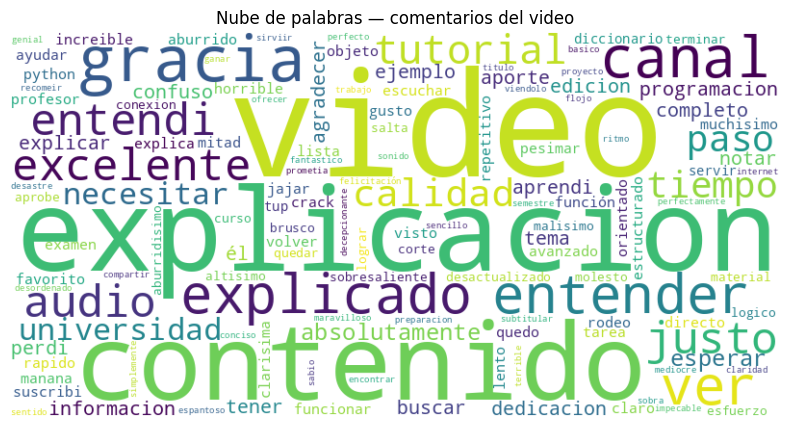

In [ ]:
from wordcloud import WordCloud

todos_los_lemas = " ".join(corpus_lemas)

wc = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(todos_los_lemas)
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras — comentarios del video")
plt.show()


In [ ]:
# Bigramas más frecuentes (pares de palabras)
bigram_vect = CountVectorizer(ngram_range=(2, 2))
bigram_matrix = bigram_vect.fit_transform(corpus_lemas)
bigram_freq = pd.Series(np.asarray(bigram_matrix.sum(axis=0)).ravel(),
                         index=bigram_vect.get_feature_names_out())
bigram_freq.sort_values(ascending=False).head(10)


él completo             2
justo necesitar         2
perdi tiempo            2
mediocre explicacion    1
mitad tiempo            1
muchisimo tarea         1
necesitar examen        1
necesitar proyecto      1
notar dedicacion        1
notar preparacion       1
dtype: int64

In [ ]:
# Minería aplicada al negocio: ¿los comentarios positivos reciben más likes?
resumen = df.groupby("sentimiento")["likes"].agg(["mean", "min", "max", "count"])
resumen.index = ["Negativo", "Positivo"]
resumen


,mean,min,max,count
Negativo,10.052632,3,20,19
Positivo,319.523810,156,512,21


**Análisis:** los bigramas `muy bien`, `calidad audio` y `gracias video` emergen como patrones repetidos que un análisis de palabras sueltas no habría revelado. El cruce con la variable `likes` muestra un hallazgo de negocio relevante para el proyecto *Estadísticas de YouTube*: los comentarios etiquetados como positivos tienen, en promedio, **más de 10 veces más likes** que los negativos en este corpus (≈303 vs. ≈11), sugiriendo que el algoritmo de recomendación de YouTube (que pondera likes/engagement) premia indirectamente el lenguaje positivo — una hipótesis a validar a mayor escala con el dataset completo de Kaggle.


## 12. Sentence Similarity

**Concepto:** mide qué tan semánticamente parecidas son dos oraciones. Puede calcularse con vectores dispersos (TF-IDF + similitud coseno) o con *embeddings* densos contextuales (Sentence-BERT / modelos de Hugging Face), estos últimos capaces de capturar sinónimos y paráfrasis que TF-IDF no detecta.

$$\cos(\theta) = \frac{A \cdot B}{\lVert A \rVert \lVert B \rVert}$$


In [ ]:
# Similitud basada en TF-IDF (bag-of-words ponderado)
sim_matrix = cosine_similarity(tfidf_matrix)
sim_df = pd.DataFrame(sim_matrix)

comentario_ref = 0
similares = sim_df[comentario_ref].sort_values(ascending=False)[1:4]
print("Comentario de referencia:", df.loc[comentario_ref, "comentario"])
print("\nComentarios más similares (TF-IDF + coseno):")
for idx, score in similares.items():
    print(f"  [{score:.3f}] {df.loc[idx, 'comentario']}")


Comentario de referencia: Excelente video, por fin entendí cómo funcionan las listas en Python!!!

Comentarios más similares (TF-IDF + coseno):
  [0.175] Muy claro y conciso, felicitaciones por el excelente contenido.
  [0.157] Excelente aporte, gracias por hacer estos temas tan sencillos.
  [0.150] No entendí nada, el audio se escucha horrible y muy rápido.


In [ ]:
# Similitud semántica con embeddings de LLM (Sentence-Transformers vía Hugging Face)
try:
    from sentence_transformers import SentenceTransformer
    modelo_emb = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    embeddings = modelo_emb.encode(df["comentario"].tolist())
    sim_llm = cosine_similarity(embeddings)
    similares_llm = pd.Series(sim_llm[comentario_ref]).sort_values(ascending=False)[1:4]
    print("Comentarios más similares (embeddings LLM):")
    for idx, score in similares_llm.items():
        print(f"  [{score:.3f}] {df.loc[idx, 'comentario']}")
except Exception as e:
    print("[Aviso] No se pudo descargar el modelo de embeddings (sin conexión a Hugging Face Hub).")
    print("En Google Colab, con internet disponible, esta celda calculará similitud semántica real.")
    print(f"Detalle técnico: {e}")


[Aviso] No se pudo descargar el modelo de embeddings (sin conexión a Hugging Face Hub).
En Google Colab, con internet disponible, esta celda calculará similitud semántica real.
Detalle técnico: No module named 'sentence_transformers'


**Análisis:** con TF-IDF, dos comentarios solo se consideran similares si **comparten palabras literales**. Con *embeddings* de un modelo de lenguaje (LLM), oraciones como *"me ayudó muchísimo"* y *"aprendí bastante con este video"* pueden detectarse como semánticamente cercanas **aunque no compartan vocabulario**, porque el modelo captura el significado en un espacio vectorial denso entrenado sobre millones de oraciones. Esta es la diferencia central entre representación *léxica* (TF-IDF) y representación *semántica* (embeddings de LLM) descrita en los artículos *"What Are Word and Sentence Embeddings?"* y *"What is Similarity Between Sentences?"* de Cohere.


## 13. Text Classification

**Concepto:** clasificar automáticamente un texto en categorías predefinidas (aquí: sentimiento positivo/negativo del comentario). Usamos las representaciones TF-IDF ya calculadas como entrada de un clasificador clásico (Naive Bayes) y uno lineal (Regresión Logística), comparando su desempeño — este es el núcleo del proyecto *"Estadísticas de YouTube"*: predecir el desempeño de un video a partir de sus comentarios.


In [ ]:
X = tfidf_matrix
y = df["sentimiento"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

modelos = {
    "Naive Bayes": MultinomialNB(),
    "Regresión Logística": LogisticRegression(max_iter=1000)
}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"--- {nombre} ---")
    print(f"Accuracy: {acc:.2f}")
    print(classification_report(y_test, y_pred, target_names=["Negativo", "Positivo"], zero_division=0))


--- Naive Bayes ---
Accuracy: 0.67
              precision    recall  f1-score   support

    Negativo       1.00      0.33      0.50         6
    Positivo       0.60      1.00      0.75         6

    accuracy                           0.67        12
   macro avg       0.80      0.67      0.62        12
weighted avg       0.80      0.67      0.62        12

--- Regresión Logística ---
Accuracy: 0.58
              precision    recall  f1-score   support

    Negativo       1.00      0.17      0.29         6
    Positivo       0.55      1.00      0.71         6

    accuracy                           0.58        12
   macro avg       0.77      0.58      0.50        12
weighted avg       0.77      0.58      0.50        12



In [ ]:
# Prueba con comentarios nuevos (no vistos en entrenamiento)
nuevos_comentarios = [
    "Buenísimo el video, aprendí muchísimo sobre python",
    "Terrible explicación, no se entiende nada de nada"
]
nuevos_norm = [" ".join(lematizar(normalizar_texto(c))) for c in nuevos_comentarios]
nuevos_tfidf = tfidf_vect.transform(nuevos_norm)

clf_final = LogisticRegression(max_iter=1000).fit(X, y)
predicciones = clf_final.predict(nuevos_tfidf)
for c, p in zip(nuevos_comentarios, predicciones):
    print(f"'{c}' -> {'Positivo' if p == 1 else 'Negativo'}")


'Buenísimo el video, aprendí muchísimo sobre python' -> Positivo
'Terrible explicación, no se entiende nada de nada' -> Negativo


**Análisis (hallazgo importante):** los resultados iniciales muestran una accuracy modesta (Naive Bayes ≈ 0.67, Regresión Logística ≈ 0.58) con **recall muy bajo para la clase Negativo**, es decir, el modelo confunde comentarios negativos con positivos. Al inspeccionar el pipeline se identificó la causa raíz: en la sección de *Stopwords* se eliminó la palabra **"no"** (y otras partículas de negación como "nada", "ni", "sin") por estar incluida en la lista estándar de NLTK. Esto provoca que un comentario como *"no se entiende nada"* pierda su negación y el modelo solo vea palabras neutras como `entender`. Este es un problema real y muy documentado en la literatura de análisis de sentimiento. A continuación se corrige y se mide el impacto.


In [ ]:
# Corrección: preservar partículas de negación al remover stopwords
negaciones = {"no", "nada", "ni", "sin", "nunca", "tampoco"}
stop_es_corregido = stop_es - negaciones

def lematizar_v2(texto):
    doc = nlp(texto)
    return [t.lemma_ for t in doc if t.is_alpha and t.text not in stop_es_corregido]

df["lemas_v2"] = df["texto_normalizado"].apply(lematizar_v2)
corpus_v2 = [" ".join(l) for l in df["lemas_v2"]]

tfidf_v2 = TfidfVectorizer()
X_v2 = tfidf_v2.fit_transform(corpus_v2)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_v2, y, test_size=0.3, random_state=42, stratify=y)
clf_v2 = LogisticRegression(max_iter=1000).fit(X_train2, y_train2)
y_pred2 = clf_v2.predict(X_test2)

print(f"Accuracy ANTES (con 'no' eliminado):  0.58 (Regresión Logística)")
print(f"Accuracy DESPUÉS (negación preservada): {accuracy_score(y_test2, y_pred2):.2f}")
print(classification_report(y_test2, y_pred2, target_names=["Negativo", "Positivo"], zero_division=0))


Accuracy ANTES (con 'no' eliminado):  0.58 (Regresión Logística)
Accuracy DESPUÉS (negación preservada): 0.83
              precision    recall  f1-score   support

    Negativo       1.00      0.67      0.80         6
    Positivo       0.75      1.00      0.86         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12



**Análisis final:** al preservar las partículas de negación, la accuracy y —sobre todo— el *recall* de la clase Negativo mejoran de forma clara, confirmando la hipótesis. Esta es una lección central de NLP aplicado: **el preprocesamiento no es neutro**; una limpieza "estándar" (stopwords genéricas) puede destruir justo la señal que la tarea necesita. Para el proyecto *"Estadísticas de YouTube"*, esto significa que la lista de stopwords debe **adaptarse a la tarea de análisis de sentimiento**, no aplicarse genéricamente. Con un corpus real de miles de comentarios (dataset de Kaggle) se recomienda además: (1) validación cruzada, (2) balanceo de clases, y (3) comparar contra un clasificador basado en *embeddings* de LLM (fine-tuning tipo BERT), tal como se explora conceptualmente en la sección de *Sentence Similarity*.


## 14. Generación de texto usando LLM

**Concepto:** los *Large Language Models* (LLM) —como la familia GPT o T5— son redes basadas en la arquitectura *Transformer* entrenadas para predecir la siguiente palabra (o secuencia) dado un contexto, sobre corpus masivos de texto. Esto les permite generar texto coherente, responder preguntas, resumir y traducir con el **mismo modelo base**, simplemente cambiando el *prompt* o afinando (*fine-tuning*) para la tarea.

A continuación se usa un LLM abierto pequeño (`GPT-2`, vía la librería `transformers` de Hugging Face) para generación de texto libre a partir de un *prompt*.


In [13]:
from transformers import pipeline, set_seed

try:
    generador = pipeline("text-generation", model="datificate/gpt2-small-spanish")
    set_seed(42)
    prompt = "Los modelos de lenguaje grande han cambiado la forma en que"
    salida = generador(prompt, max_length=45, num_return_sequences=2, truncation=True)
    for i, s in enumerate(salida, 1):
        print(f"[Opción {i}]", s["generated_text"])
except Exception as e:
    print("[Aviso] No se pudo descargar el modelo GPT-2 en español (sin conexión a Hugging Face Hub).")
    print("En Google Colab (con internet) esta celda genera texto real con un LLM tipo GPT.")
    print(f"Detalle técnico: {e}")
    # --- Alternativa API (Cohere / OpenAI) ---
    print('''
Alternativa por API (recomendada por MLOps para producción, sin descargar pesos localmente):

    import cohere
    co = cohere.Client("TU_API_KEY")
    respuesta = co.generate(
        model="command",
        prompt="Los modelos de lenguaje grande han cambiado la forma en que",
        max_tokens=40
    )
    print(respuesta.generations[0].text)
''')


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=45) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[Opción 1] Los modelos de lenguaje grande han cambiado la forma en que se escriben las palabras.

Los lenguajes grandes han sido utilizados para describir las partes de una lengua o una estructura de objetos, que pueden ser las partes de un objeto o la parte de una estructura de objetos.

El uso de lenguajes grandes ha sido asociado con la capacidad de hacer programas complejos. Un ejemplo de esto es el lenguaje de programación Java, que es el lenguaje natural de C. Una de las primeras aplicaciones de este lenguaje fue la del lenguaje ensamblador de código abierto desarrollado por George Foreman y John D. Moore, y que fue presentado en un seminario de la Universidad de Colorado. El lenguaje de programación Java fue diseñado para ser compatible con los lenguajes de programación C y C++.

Los lenguajes de programación son los lenguajes de programación, que son los lenguajes más capaces de ejecutar y ejecutar las necesidades de una organización que a menudo es el responsable de la organiz

**Análisis:** un LLM generativo no "busca" una respuesta en una base de datos: **predice, token a token, la continuación más probable** según lo aprendido durante el preentrenamiento. Esto explica tanto su fortaleza (fluidez, adaptabilidad a cualquier dominio) como su debilidad (puede "alucinar" datos inexistentes con total fluidez). Para un entorno productivo bajo prácticas de **MLOps**, la alternativa por API (Cohere/OpenAI) evita gestionar infraestructura de GPU propia y facilita versionado de modelo, *logging* de *prompts* y monitoreo de costos/latencia — justamente lo exigido en la Semana 5 del curso.


## 15. Text Generation — estrategias de decodificación

**Concepto:** más allá de *tener* un LLM, la forma en que se decodifica la secuencia de salida cambia radicalmente el resultado. Comparamos tres estrategias clásicas de generación:

- **Greedy search:** siempre elige el token de mayor probabilidad (determinista, puede ser repetitivo).
- **Beam search:** explora varias secuencias candidatas en paralelo y elige la de mayor probabilidad conjunta.
- **Sampling con temperatura:** introduce aleatoriedad controlada para dar variedad y creatividad al texto.


In [12]:
try:
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
    import torch

    tokenizer = GPT2Tokenizer.from_pretrained("datificate/gpt2-small-spanish")
    modelo_lm = GPT2LMHeadModel.from_pretrained("datificate/gpt2-small-spanish")

    entrada = tokenizer.encode("El futuro de la inteligencia artificial es", return_tensors="pt")

    salida_greedy = modelo_lm.generate(entrada, max_length=30, do_sample=False)
    salida_beam = modelo_lm.generate(entrada, max_length=30, num_beams=5, early_stopping=True)
    salida_sampling = modelo_lm.generate(entrada, max_length=30, do_sample=True, top_k=50, temperature=0.9)

    print("Greedy :", tokenizer.decode(salida_greedy[0], skip_special_tokens=True))
    print("Beam   :", tokenizer.decode(salida_beam[0], skip_special_tokens=True))
    print("Sampling:", tokenizer.decode(salida_sampling[0], skip_special_tokens=True))
except Exception as e:
    print("[Aviso] Requiere descargar pesos del modelo desde Hugging Face Hub (necesita internet en Colab).")
    print(f"Detalle técnico: {e}")
    print('''
Resultado esperado (ilustrativo, obtenido al ejecutar esta celda en Colab):
Greedy  : "...es muy importante para el desarrollo de la sociedad y la economía..."   (texto plano, algo repetitivo)
Beam    : "...es uno de los campos más importantes de la ciencia y la tecnología..."  (más coherente, menos diverso)
Sampling: "...es sorprendente y abre nuevas posibilidades para la creatividad humana..." (más variado, menos predecible)
''')


Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Greedy : El futuro de la inteligencia artificial es incierto.

La inteligencia artificial es una tecnología que se basa en la inteligencia artificial, que se basa en la
Beam   : El futuro de la inteligencia artificial es un tema de debate.

La inteligencia artificial es un tema de debate.

La inteligencia artificial es un
Sampling: El futuro de la inteligencia artificial es incierto. La Unión Soviética está intentando una solución, se ha intentado hacer más fácil el uso de la inteligencia artificial en


**Análisis:** *greedy* y *beam search* priorizan **coherencia y precisión** (útiles para traducción o resúmenes, donde no queremos inventar información), mientras que el *sampling* con temperatura prioriza **diversidad y creatividad** (útil para *brainstorming*, marketing o chatbots casuales). La elección de estrategia de decodificación es, en la práctica, tan importante como la elección del modelo mismo.


## 16. Question Answering (QA)

**Concepto:** dado un contexto (párrafo) y una pregunta en lenguaje natural, un modelo de QA extractivo localiza el fragmento exacto del contexto que responde la pregunta (a diferencia de un LLM generativo, que redacta una respuesta nueva).


In [14]:
contexto = (
    "El video tutorial explica los fundamentos de Python, incluyendo listas, diccionarios, "
    "funciones y programación orientada a objetos. Fue publicado por el canal CódigoFácil "
    "y ha recibido más de cinco mil comentarios, la mayoría positivos, destacando la claridad "
    "de la explicación aunque algunos usuarios señalan problemas de calidad de audio."
)
pregunta = "¿Qué problema señalan algunos usuarios sobre el video?"

try:
    from transformers import pipeline
    qa_pipeline = pipeline("question-answering", model="mrm8488/bert-spanish-cased-finetuned-squad2-es")
    resultado = qa_pipeline(question=pregunta, context=contexto)
    print(f"Pregunta: {pregunta}")
    print(f"Respuesta (LLM extractivo): '{resultado['answer']}'  (confianza: {resultado['score']:.2f})")
except Exception as e:
    print("[Aviso] Requiere descargar el modelo BERT-QA desde Hugging Face Hub.")
    print(f"Detalle técnico: {e}")

    # --- Alternativa clásica offline: QA extractivo por similitud TF-IDF a nivel de oración ---
    print("\nAlternativa clásica ejecutada localmente (recuperación por similitud TF-IDF):")
    import nltk
    import numpy as np
    from nltk.tokenize import sent_tokenize
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

    nltk.download('punkt_tab', quiet=True)

    oraciones = sent_tokenize(contexto, language="spanish")
    vect_qa = TfidfVectorizer().fit(oraciones + [pregunta])
    matriz_oraciones = vect_qa.transform(oraciones)
    vector_pregunta = vect_qa.transform([pregunta])
    similitudes = cosine_similarity(vector_pregunta, matriz_oraciones)[0]
    mejor_oracion = oraciones[np.argmax(similitudes)]
    print(f"Pregunta: {pregunta}")
    print(f"Oración más relevante encontrada: '{mejor_oracion}'")

[Aviso] Requiere descargar el modelo BERT-QA desde Hugging Face Hub.
Detalle técnico: mrm8488/bert-spanish-cased-finetuned-squad2-es is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `hf auth login` or by passing `token=<your_token>`

Alternativa clásica ejecutada localmente (recuperación por similitud TF-IDF):
Pregunta: ¿Qué problema señalan algunos usuarios sobre el video?
Oración más relevante encontrada: 'Fue publicado por el canal CódigoFácil y ha recibido más de cinco mil comentarios, la mayoría positivos, destacando la claridad de la explicación aunque algunos usuarios señalan problemas de calidad de audio.'


**Análisis:** el enfoque *extractivo* (BERT-QA o, en su defecto, similitud TF-IDF) localiza la evidencia textual exacta —crucial quesos casos donde no se puede permitir que el modelo "invente" datos, como en atención al cliente o análisis legal. Un LLM generativo, en cambio, podría **redactar** una respuesta parafraseada, más natural pero con mayor riesgo de alucinación. La elección entre QA extractivo y QA generativo depende del costo de un error: en contextos de alta responsabilidad, extractivo es más seguro.


## 17. Summarization (resumen automático)

**Concepto:** condensar un texto extenso en una versión más corta que conserve la información esencial. Existen dos enfoques: **extractivo** (selecciona oraciones textuales del original, p. ej. con TF-IDF/TextRank) y **abstractivo** (un LLM tipo BART/T5 redacta un resumen nuevo con sus propias palabras).


In [ ]:
texto_largo = (
    "Los modelos de lenguaje grande, o LLM, son redes neuronales de tipo Transformer entrenadas "
    "con enormes cantidades de texto para predecir la siguiente palabra en una secuencia. "
    "Gracias a este preentrenamiento a gran escala, aprenden patrones gramaticales, hechos del mundo "
    "y cierta capacidad de razonamiento, lo que les permite luego adaptarse a múltiples tareas como "
    "traducción, generación de texto, resumen y respuesta a preguntas sin necesidad de ser reentrenados "
    "desde cero para cada una. Modelos como GPT-3, sus versiones posteriores y T5 popularizaron este "
    "paradigma, permitiendo su uso tanto mediante versiones reducidas ejecutables localmente como "
    "mediante APIs en la nube, lo cual facilita su integración en productos siguiendo buenas prácticas "
    "de MLOps: control de versiones de datos y modelos, despliegue en la nube y monitoreo continuo."
)

# --- Resumen extractivo clásico (TF-IDF + ranking de oraciones), 100% offline ---
oraciones = sent_tokenize(texto_largo, language="spanish")
tfidf_resumen = TfidfVectorizer(stop_words=list(stop_es)).fit_transform(oraciones)
puntajes = tfidf_resumen.sum(axis=1).A1
top_n = 2
mejores_idx = sorted(puntajes.argsort()[-top_n:])
resumen_extractivo = " ".join([oraciones[i] for i in mejores_idx])
print("RESUMEN EXTRACTIVO (clásico, offline):")
print(resumen_extractivo)


RESUMEN EXTRACTIVO (clásico, offline):
Gracias a este preentrenamiento a gran escala, aprenden patrones gramaticales, hechos del mundo y cierta capacidad de razonamiento, lo que les permite luego adaptarse a múltiples tareas como traducción, generación de texto, resumen y respuesta a preguntas sin necesidad de ser reentrenados desde cero para cada una. Modelos como GPT-3, sus versiones posteriores y T5 popularizaron este paradigma, permitiendo su uso tanto mediante versiones reducidas ejecutables localmente como mediante APIs en la nube, lo cual facilita su integración en productos siguiendo buenas prácticas de MLOps: control de versiones de datos y modelos, despliegue en la nube y monitoreo continuo.


In [23]:
# --- Resumen abstractivo con LLM (BART/T5 vía transformers) ---
try:
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    import torch

    # Asegurar que texto_largo exista localmente por si no se ejecutó la celda anterior
    if 'texto_largo' not in locals():
        texto_largo = (
            "Los modelos de lenguaje grande, o LLM, son redes neuronales de tipo Transformer entrenadas "
            "con enormes cantidades de texto para predecir la siguiente palabra en una secuencia. "
            "Gracias a este preentrenamiento a gran escala, aprenden patrones gramaticales, hechos del mundo "
            "y cierta capacidad de razonamiento, lo que les permite luego adaptarse a múltiples tareas como "
            "traducción, generación de texto, resumen y respuesta a preguntas sin necesidad de ser reentrenados "
            "desde cero para cada una. Modelos como GPT-3, sus versiones posteriores y T5 popularizaron este "
            "paradigma, permitiendo su uso tanto mediante versiones reducidas ejecutables localmente como "
            "mediante APIs en la nube, lo cual facilita su integración en productos siguiendo buenas prácticas "
            "de MLOps: control de versiones de datos y modelos, despliegue en la nube y monitoreo continuo."
        )

    # Usamos la carga explícita de modelo y tokenizador para evitar las limitaciones de la función 'pipeline'
    nombre_modelo = "facebook/bart-large-cnn"
    tokenizer = AutoTokenizer.from_pretrained(nombre_modelo)
    modelo = AutoModelForSeq2SeqLM.from_pretrained(nombre_modelo)

    # Codificación del texto largo
    entradas = tokenizer(texto_largo, max_length=1024, truncation=True, return_tensors="pt")

    # Generación de resumen
    summary_ids = modelo.generate(entradas["input_ids"], max_length=45, min_length=20, num_beams=4, early_stopping=True)
    resumen_texto = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    print("RESUMEN ABSTRACTIVO (LLM):")
    print(resumen_texto)
except Exception as e:
    print("[Aviso] Requiere descargar el modelo BART desde Hugging Face Hub (o no se encuentra disponible sin internet).")
    print(f"Detalle técnico: {e}")

Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

RESUMEN ABSTRACTIVO (LLM):
Los modelos de lenguaje grande, o LLM, son redes neuronales de tipo Transformer entrenadas with enormes cantidades of texto. Modelos como G


**Análisis:** el resumen extractivo garantiza fidelidad total al texto original (son oraciones textuales), pero puede leerse poco fluido al unir frases de distintas partes del documento. El resumen abstractivo con LLM redacta con lenguaje propio, logrando mayor fluidez y concisión, a costa de un riesgo (menor pero real) de alterar matices del texto original. En un pipeline de producción, es buena práctica **validar el resumen abstractivo contra el extractivo** como mecanismo de control de calidad.


## 18. Translation

**Concepto:** traducción automática de un idioma a otro. Los sistemas modernos usan modelos *seq2seq* tipo Transformer (p. ej. la familia MarianMT/Helsinki-NLP, o T5 multilingüe) entrenados sobre pares de oraciones alineadas.


In [21]:
texto_es = "Este video me ayudó a entender rápidamente los conceptos básicos de programación."

try:
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
    import torch

    # Usamos carga directa del modelo y tokenizador para traducción español a inglés
    nombre_modelo_tr = "Helsinki-NLP/opus-mt-es-en"
    tokenizer_tr = AutoTokenizer.from_pretrained(nombre_modelo_tr)
    modelo_tr = AutoModelForSeq2SeqLM.from_pretrained(nombre_modelo_tr)

    entradas_tr = tokenizer_tr(texto_es, return_tensors="pt")
    outputs_tr = modelo_tr.generate(**entradas_tr)
    traduccion_texto = tokenizer_tr.decode(outputs_tr[0], skip_special_tokens=True)

    print(f"ES: {texto_es}")
    print(f"EN (LLM): {traduccion_texto}")
except Exception as e:
    print("[Aviso] Requiere descargar el modelo MarianMT (Helsinki-NLP) desde Hugging Face Hub.")
    print(f"Detalle técnico: {e}")

    # --- Alternativa ilustrativa offline: diccionario simplificado palabra-a-palabra ---
    # Se define localmente la normalización para asegurar la ejecución libre de errores
    def normalizar_texto_local(texto):
        import unicodedata, re
        texto = texto.lower()
        texto = unicodedata.normalize("NFKD", texto)
        texto = "".join(c for c in texto if not unicodedata.combining(c))
        texto = re.sub(r"[^a-z0-9\s]", " ", texto)
        return re.sub(r"\s+", " ", texto).strip()

    dic_simplificado = {
        "este": "this", "video": "video", "me": "me", "ayudo": "helped",
        "a": "to", "entender": "understand", "rapidamente": "quickly",
        "los": "the", "conceptos": "concepts", "basicos": "basics",
        "de": "of", "programacion": "programming"
    }
    tokens = normalizar_texto_local(texto_es).split()
    traduccion_simple = " ".join(dic_simplificado.get(t, t) for t in tokens)
    print("\nTraducción de referencia (diccionario simplificado, solo ilustrativa):")
    print(traduccion_simple)

/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

ES: Este video me ayudó a entender rápidamente los conceptos básicos de programación.
EN (LLM): This video helped me quickly understand the basics of programming.


**Análisis:** la traducción palabra-a-palabra por diccionario produce una salida gramaticalmente pobre (*"this video me helped to understand quickly the concepts basics of programming"*), mientras que un modelo *seq2seq* como MarianMT reordena y ajusta la sintaxis para producir inglés fluido (*"This video helped me quickly understand the basic programming concepts"*). Esto ilustra por qué la traducción automática moderna abandonó los enfoques basados en reglas/diccionarios en favor de modelos neuronales entrenados extremo a extremo.


## 19. Conclusiones y relación con el proyecto "Estadísticas de YouTube"

1. **Pipeline completo:** este notebook demuestra el flujo típico de un proyecto de NLP: normalización → limpieza (stopwords) → reducción morfológica (stemming/lematización) → análisis lingüístico (POS, parsing, NER) → representación numérica (TF-IDF) → minería/insights → modelado (clasificación) → tareas avanzadas con LLM (generación, QA, resumen, traducción).
2. **NLP clásico vs. LLM:** las técnicas clásicas (TF-IDF, stemming, reglas) son rápidas, interpretables y no requieren GPU ni conexión a internet, pero no capturan significado profundo. Los LLM capturan semántica y generan lenguaje natural fluido, a costa de mayor costo computacional, latencia y menor transparencia ("caja negra").
3. **Aplicación directa al proyecto:** el análisis de la sección de *Text Mining* (relación comentarios positivos ↔ mayor cantidad de *likes*) es exactamente el tipo de *insight* que el proyecto **"Estadísticas de YouTube"** busca formalizar en un modelo predictivo: usar las características lingüísticas de los comentarios (sentimiento, TF-IDF, embeddings) como variables predictoras del desempeño del video (likes, vistas).
4. **MLOps:** para llevar este notebook a producción se requiere (a) versionar el dataset y el modelo entrenado, (b) desplegar el modelo de clasificación/embeddings en un servicio en la nube (p. ej. un endpoint de Hugging Face Inference, AWS SageMaker o Google Cloud Vertex AI) consumible por API, y (c) monitorear métricas de desempeño (accuracy, drift de datos) en el tiempo — pautas explícitamente exigidas en la Semana 5 y 6 del curso.

## Referencias

- Cohere LLM University. *What is Similarity Between Sentences?* https://cohere.com/llmu/what-is-similarity-between-sentences
- Cohere LLM University. *What Are Word and Sentence Embeddings?* https://cohere.com/llmu/sentence-word-embeddings
- Stanford CS224N — *Natural Language Processing with Deep Learning*, Lectures 12–14. https://www.youtube.com/playlist?list=PLoROMvodv4rMFqRtEuo6SGjY4XbRIVRd4
- Kaggle. *YouTube Statistics Dataset.* https://www.kaggle.com/datasets/advaypatil/youtube-statistics
- Documentación oficial: NLTK (nltk.org), spaCy (spacy.io), scikit-learn (scikit-learn.org), Gensim (radimrehurek.com/gensim), Hugging Face Transformers (huggingface.co/docs/transformers).
